In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import shap

# Load preprocessed California Housing Dataset

In [4]:
data = pd.read_parquet("../data/california_housing_prices.parquet")
X = data.drop(columns="HousePrice")
y = data["HousePrice"]

## Split train/ test data in 0.75:0.25 ratio

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(
    f"Train data rows: {len(X_train)} \n" 
    f"Test data rows: {len(X_test)}"
)

X_train.head()

Train data rows: 14736 
Test data rows: 4912


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
4081,34.62,52.0,4.953271,1.121495,1127.0,3.510903,34.12,-118.21
1511,50.50,32.0,6.213873,0.982659,486.0,2.809249,37.90,-122.08
8270,60.20,19.0,5.368794,1.049645,361.0,2.560284,33.87,-118.37
3942,41.15,28.0,5.455064,1.068474,1790.0,2.553495,34.19,-118.61
10155,23.95,25.0,4.798722,1.146965,891.0,1.423323,33.61,-117.71


## Train Linear Regression model and make predictions on test data

In [194]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Evaluate model using set of performance metrics

The linear regression model achieves an MAE of 38.89, meaning that its predictions are off by an average of approximately $38,890 from the actual median house value of $172,250. The RMSE of 64.11 is considerably higher than the MAE, indicating that the model makes some relatively large prediction errors, since RMSE penalizes larger errors more strongly due to it taking the square of the residual.

The MAPE of 31.01% indicates that the model's predictions deviate from the actual house values by approximately 31% on average relative to their true values. This suggests that the model has substantial prediction errors and that a simple linear relationship between the features and house prices is not sufficient to fully capture the underlying patterns in the data.

Finally, the model achieves an R² score of 0.5673, meaning that the model explains approximately 56.7% of the variance in house prices. The remaining 43.3% of the variance is not explained by the model.

Overall, the linear regression model provides a reasonable baseline, but its performance indicates that house prices are influenced by relationships that are more complex than can be captured by a purely linear model.

In [195]:
mae = median_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(
    f"MAE:  {mae:.4f} \n"
    f"MAPE: {mape:.4f} \n" 
    f"RMSE: {rmse:.4f} \n"
    f"R²:   {r2:.4f}"
)

MAE:  38.8919 
MAPE: 0.3101 
RMSE: 64.1134 
R²:   0.5673


## Visualizing the errors

In [197]:
percentage_errors = np.abs((y_test - y_pred) / y_test)


fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=list(range(len(y_test[:15]))),
        y=y_test[:15],
        name="Actual",
        opacity=0.7
    )
)

fig.add_trace(
    go.Bar(
        x=list(range(len(y_pred[:15]))),
        y=y_pred[:15],
        name="Predicted",
        opacity=0.7
    )
)

fig.add_trace(
    go.Scatter(
        x=list(range(len(percentage_errors[:15]))),
        y=round(percentage_errors[:15] * 100, 2),
        name="PE (%)",
        mode="lines",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Actual vs. Predicted House Prices (for 15 samples)",
    xaxis_title="Test Sample",
    yaxis=dict(
        title="House Value ($1,000s)"
    ),
    yaxis2=dict(
        title="Percentage Error (%)",
        overlaying="y",
        side="right"
    ),
    barmode="group",
    hovermode="x unified"
)

fig.show()

The following plot illustrates the magnitude of the prediction errors by comparing the actual and predicted house prices. The dashed line represents perfect predictions, where the predicted price is equal to the actual price. Therefore, predictions closer to this line correspond to smaller absolute errors, while points further away indicate larger errors. It can be observed that the model generally performs better for lower- and medium-priced houses, whereas its predictions become increasingly inaccurate for higher-priced houses. This suggests that the linear regression model struggles to capture the factors associated with more expensive properties and therefore tends to underestimate or otherwise poorly predict house prices at the upper end of the distribution.


In [198]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
})

fig = px.scatter(
    results,
    x="Actual",
    y="Predicted",
    title="Actual vs. Predicted House Prices",
    labels={
        "Actual": "Actual Price ($1,000)",
        "Predicted": "Predicted Price ($1,000)"
    },
)

# perfect prediction line
min_val = min(results["Actual"].min(), results["Predicted"].min())
max_val = max(results["Actual"].max(), results["Predicted"].max())

fig.add_shape(
    type="line",
    x0=min_val,
    y0=min_val,
    x1=max_val,
    y1=max_val,
    line=dict(dash="dash")
)

fig.update_layout(
    xaxis=dict(
        range=[0, 500],
        type="linear",
    ),
    yaxis=dict(
        range=[0, 500],
        type="linear",
    ),
)

fig.show()

The next plot further explores this phenomenon, confirming that MAE increases alongside house prices. However, because properties valued at $300,000 and above represent a small fraction of the overall dataset, these higher individual errors have a minimal impact on the overall MAE score.

In [199]:
results["MAE"] = np.abs(y_test - y_pred)
results["bucket"] = (results["Actual"] // 50) * 50

bucketed_mae = (
    results
    .groupby("bucket")["MAE"]
    .mean()
    .reset_index()
)

bucket_size = (
    results
    .groupby("bucket")
    .size()
    .reset_index(name="count")
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=bucketed_mae["bucket"],
        y=bucketed_mae["MAE"],
        name="Mean MAE",
    )
)

fig.add_trace(
    go.Scatter(
        x=bucket_size["bucket"],
        y=bucket_size["count"],
        name="Bucket Size",
        mode="markers+lines",
        yaxis="y2",
    )
)

fig.update_layout(
    title="Mean MAE and Sample Count by Actual House Price",
    xaxis=dict(title="Actual Price Bucket ($1,000)"),
    yaxis=dict(title="Mean Absolute Error ($1,000)"),
    yaxis2=dict(
        title="Bucket Size (n samples)",
        overlaying="y",
        side="right",
        showgrid=False
    ),
    barmode="group",
    hovermode="x unified"
)

fig.show()

# Linear Model Coefficients

Model coefficients can be extracted directly via the `.coef_` property. Each coefficient $\beta_i$ (where $i$ indexes the feature set $F$) defines the slope of the linear decision boundary. Mathematically, these parameters represent the partial derivatives of the target variable, housing price, with respect to each independent feature, assuming all other variables remain constant. We will denote the absolute values here as this will make it easier to compare them shap values.

In [200]:
linear_regression_coefs = pd.DataFrame(
    {
        "feature": X.columns,
        "model_coef": model.coef_,
        "abs_model_coef": np.abs(model.coef_)
    }
).set_index("feature")

linear_regression_coefs

,model_coef,abs_model_coef
feature,,
MedInc,4.270771,4.270771
HouseAge,0.778629,0.778629
AveRooms,-10.388123,10.388123
AveBedrms,58.032483,58.032483
Population,0.000481,0.000481
AveOccup,-0.303816,0.303816
Latitude,-37.991286,37.991286
Longitude,-39.629068,39.629068


### Scale of the features

The features of the underlying dataset lie different scales with different magnitudes. Standard scaling normalizes feature distributions to have a mean of 0 and a standard deviation of 1 ($z = \frac{x - \mu}{\sigma}$). This preprocessing step is essential for coefficient extraction because raw features span drastically different magnitudes. For example, `Population` scales up to 35,682 while `HouseAge` maxes out at 52. Without scaling, raw regression coefficients are distorted by these structural unit differences rather than true economic impact, making it impossible to compare feature importance. This makes sense as features with greater ranges must have smaller coefficients to prevent them from exploding the prediction past the target value and the other way around. Placing all variables on a level playing field ensures the resulting coefficients faithfully represent their relative influence on model predictions.

In [201]:
min_feature_values = np.min(X, axis=0)
max_feature_values = np.max(X, axis=0)

linear_regression_coefs["min_feature_values"] = min_feature_values
linear_regression_coefs["max_feature_values"] = max_feature_values

linear_regression_coefs

,model_coef,abs_model_coef,min_feature_values,max_feature_values
feature,,,,
MedInc,4.270771,4.270771,5.000000,150.000000
HouseAge,0.778629,0.778629,1.000000,52.000000
AveRooms,-10.388123,10.388123,0.846154,132.533333
AveBedrms,58.032483,58.032483,0.333333,34.066667
Population,0.000481,0.000481,3.000000,35682.000000
AveOccup,-0.303816,0.303816,0.692308,1243.333333
Latitude,-37.991286,37.991286,32.540000,41.950000
Longitude,-39.629068,39.629068,-124.350000,-114.310000


In [202]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [203]:
linear_regression_coefs["scaled_model_coef"] = pipeline.named_steps["model"].coef_
linear_regression_coefs["scaled_abs_model_coef"] = np.abs(pipeline.named_steps["model"].coef_)
linear_regression_coefs

,model_coef,abs_model_coef,min_feature_values,max_feature_values,scaled_model_coef,scaled_abs_model_coef
feature,,,,,,
MedInc,4.270771,4.270771,5.000000,150.000000,67.239514,67.239514
HouseAge,0.778629,0.778629,1.000000,52.000000,9.733521,9.733521
AveRooms,-10.388123,10.388123,0.846154,132.533333,-24.726858,24.726858
AveBedrms,58.032483,58.032483,0.333333,34.066667,27.648503,27.648503
Population,0.000481,0.000481,3.000000,35682.000000,0.548341,0.548341
AveOccup,-0.303816,0.303816,0.692308,1243.333333,-3.727066,3.727066
Latitude,-37.991286,37.991286,32.540000,41.950000,-81.792440,81.792440
Longitude,-39.629068,39.629068,-124.350000,-114.310000,-79.322556,79.322556


# SHAP Values

First, we will define our background data and choose the Exact Explainer from the `shap` library. The Exact Explainer is computationally feasible here because our dataset contains 8 features ($2^8 = 256$ subsets) and `X_test` has $\approx 5,000$ samples. We will apply the Exact Explainer directly, following the in-depth implementation demonstrated in the `shap_computation.ipynb` notebook. By using SHAP's `Explainer` class and allowing it to automatically select the most appropriate algorithm for the model, `LinearExplainer` would be chosen for the linear regression model. This would reduce the computation time from approximately 10 seconds with `ExactExplainer` to just 0.07 seconds with `LinearExplainer`. However, since `ExactExplainer` calculates exact shap values rather than approximating them by evaluating all possible feature subsets and the computation time remains sufficiently low for our dataset, we will use `ExactExplainer` in this case.

In [204]:
X_background = X_train.sample(n=100, random_state=42)
explainer = shap.ExactExplainer(model.predict, X_background)
shap_values = explainer(X_test)

In [205]:
mean_shap_values = np.mean(np.abs(shap_values.values), axis=0)
linear_regression_coefs["abs_shap_value"] = mean_shap_values
linear_regression_coefs.sort_values(by=["abs_shap_value"], ascending=False, inplace=True)
linear_regression_coefs = linear_regression_coefs.reset_index()

### SHAP vs. linear model coefficients

While raw model coefficients reveal a feature's mathematical sensitivity, they are heavily distorted by arbitrary unit scales, forcing features with massive numeric ranges (like `Population`) to artificially shrink to compensate. Applying standard scaling corrects this distortion by evaluating all variables on a level playing field of standard deviations, but even scaled coefficients only describe theoretical model behavior. SHAP values provide a superior evaluation because they measure true real-world impact rather than just sensitivity. By multiplying a feature's coefficient by how far a specific data point actually deviates from the dataset average, SHAP accounts for the natural distribution of the data. This reveals that while a model might be mathematically highly sensitive to a feature like average bedrooms, its actual economic impact on predictions is minimal compared to highly variable features like geographic location, making SHAP the gold standard for practical interpretability.

In conclusion, while scaled model coefficients come closer to shap values than raw coefficients, they still only describe theoretical model sensitivity and not actual real-world impact. Scaled coefficiets measure what happens if a feature shifts by an arbitrary 1.0 standard deviation in isolation. However, real world datapoints do not move uniformly. Additionally, features with extreme outliers artificially inflate the standard deviation and therefor variance, which creates unnaturally large coefficients. So a model can be mathematically highly sensitive to a feature but if that feature rarely varies across real homes (like Average Bedrooms), its ability to explain price differences across neighboorhoods is low.

In [206]:
fig = go.Figure()

fig.add_trace(go.Bar(
    y=linear_regression_coefs['abs_model_coef'],
    x=linear_regression_coefs['feature'],
    name='abs coef.',
))

fig.add_trace(go.Bar(
    y=linear_regression_coefs['scaled_abs_model_coef'],
    x=linear_regression_coefs['feature'],
    name='scaled abs coef.',
))

fig.add_trace(go.Bar(
    y=linear_regression_coefs['abs_shap_value'],
    x=linear_regression_coefs['feature'],
    name='mean abs shap',
))

fig.update_layout(
    title='Feature Metrics Comparison: Coefficients vs. SHAP',
    barmode='group',
    xaxis_title='Feature',
    yaxis_title='Value',
    hovermode="x unified"
)

fig.show()

## SHAP value plots

To evaluate the real-world contribution of each feature to predicted house prices, we will analyze visualizations derived from the calculated SHAP values. A detailed mathematical breakdown of SHAP value calculations and the expected baseline model output, E[f(x)], can be found in the accompanying `shap_computation.ipynb` notebook.

### Bar Plot

The SHAP bar plot displays the mean absolute SHAP value for each feature across the test dataset. Formally, for a given feature $j$, this metric is defined as:

$$
\text{mean}(\vert{}\phi_j\vert{}) = \frac{1}{N} \sum_{i=1}^{N} \vert{}\phi_i^{(j)}\vert{}
$$

where $N$ is the total number of samples in $X_{\text{test}}$ and $\phi_i^{(j)}$ represents the calculated Shapley value for feature $j$ on the $i$-th sample.


Because these values are averaged magnitudes, the bar plot indicates feature impact without revealing directionality, showing which features move predictions the most, regardless of whether they push housing prices higher or lower.

`Latitude`, `Longitude`, and `MedInc` emerge as the dominant drivers with the highest marginal contributions to model outputs. Conversely, `Population` and `AveOccup` demonstrate negligible practical impact on house price predictions.

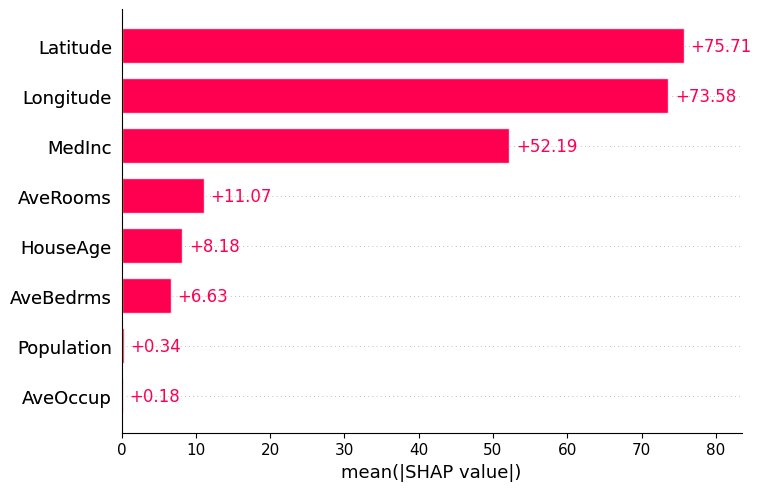

In [207]:
shap.plots.bar(shap_values)

### Individual Sample Plots

Plotting the SHAP value composition for an individual sample, rather than the aggregated values shown in the bar plot above, reveals the contribution and magnitude of each feature for that specific prediction.

In this example, the house's geographic location has a negligible net contribution to the predicted housing price. Although latitude and longitude each contribute to the prediction, their effects largely oppose and cancel each other out. Instead, the primary drivers of the predicted housing price are the median income (`MedInc`) in the neighboorhood and house age (`HouseAge`).

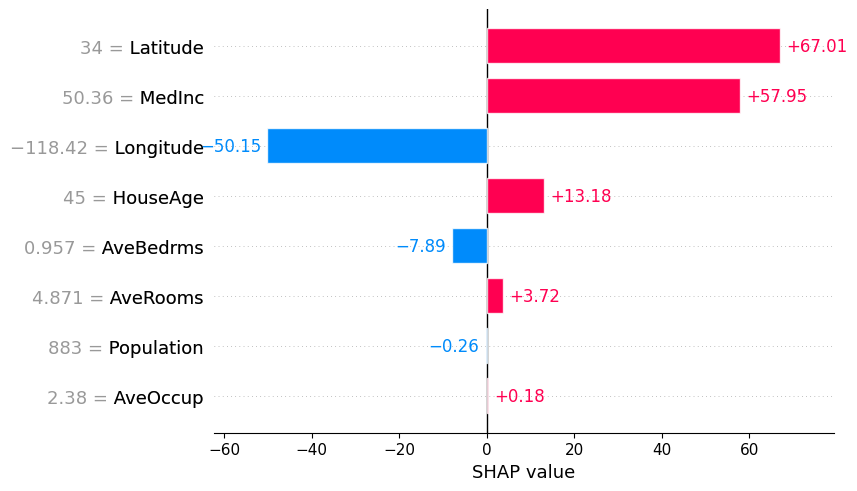

In [212]:
shap.plots.bar(shap_values[0])

However, the contribution of each feature to an individual prediction is best illustrated on a per-sample basis using a waterfall plot. Here, SHAP values can be directly interpreted as changes in the predicted housing price, measured in $1,000s. By summing all SHAP values and adding them to the baseline value (the model's expected prediction over the test dataset, essentially the mean prediction over all test samples) we arrive at the final model prediction of $277,656. This follows from the efficiency property of SHAP values, which guarantees that the baseline prediction plus the sum of all feature contributions exactly reconstructs the model's prediction for the sample.

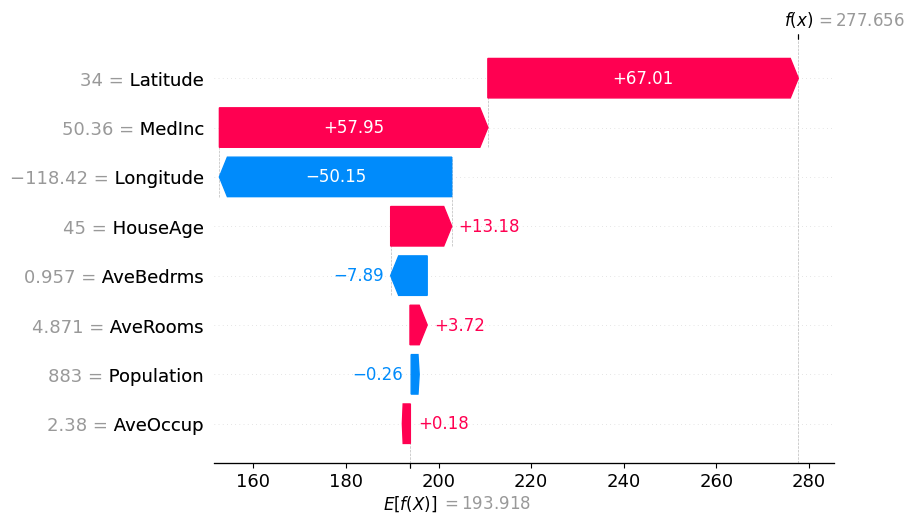

In [214]:
shap.plots.waterfall(shap_values[0])

### Global Feature Importance

The beeswarm plot provides a global overview of how each feature influences the model's predictions across all test samples. Features are ordered by their mean absolute SHAP value, with the most influential features appearing at the top. Each point represents one sample, its horizontal position indicates the SHAP value and its color represents the corresponding feature value (red = high, blue = low).

The model is primarily driven by `Latitude`, `Longitude` and `MedInc`. The geographic features show a particularly clear pattern: low latitude values (blue) tend to have positive SHAP values, while high latitude values (red) tend to have negative SHAP values. The same pattern is visible for `Longitude`, where lower values generally increase the prediction and higher values decrease it. This indicates that the geographical location of a property has a substantial impact on its predicted price.

`MedInc` exhibits the strongest and most consistent relationship with the prediction. High median income values (red) predominantly have positive SHAP values, increasing the predicted housing price, whereas lower income values tend to have a smaller or negative contribution.

`AveRooms` also has a notable impact, although its relationship is less straightforward. Most observations are concentrated around zero, while several samples exhibit substantial negative SHAP values. This demonstrates that the effect of a feature cannot necessarily be inferred by simply comparing its value to the global feature mean; SHAP values describe the feature's contribution to the model prediction in the context of each individual sample.

The remaining features `HouseAge`, `AveBedrms`, `Population` and `AveOccup` have considerably smaller average impacts. However, some individual observations show large SHAP values, particularly for `AveBedrms`, indicating that a feature with low global importance can still be highly influential for specific predictions.

Overall, the beeswarm plot shows that the model relies predominantly on geographical location and neighborhood income, while the remaining features generally play a smaller role in determining the predicted housing price.


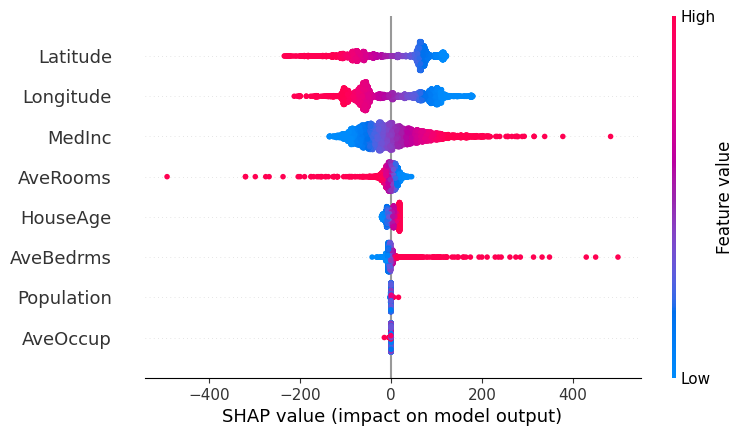

In [216]:
shap.plots.beeswarm(shap_values)

### SHAP Dependence Plot

The dependence plot shows how the value of `AveRooms` affects its SHAP value across the test dataset. The x-axis represents the actual feature value, while the y-axis shows its corresponding contribution to the model output. The color encodes `AveBedrms`, highlighting potential interactions between the two features.

For typical observations, `AveRooms` has a relatively small positive contribution at low values. As `AveRooms` increases, its SHAP value decreases linearly (since the model we used is linear), meaning that higher values of `AveRooms` increasingly reduce the predicted housing price. This relationship becomes particularly pronounced for the few observations with unusually high room counts.

The plot also reveals several extreme outliers. A small number of samples have exceptionally large `AveRooms` values, with one observation exceeding 50 rooms. These observations receive strongly negative SHAP values of up to approximately $500, indicating that the model interprets such unusually high room counts as a substantial downward adjustment to the predicted price.

The color encoding further suggests an interaction with `AveBedrms`: the observations with higher `AveBedrms` values tend to occur at the higher `AveRooms` values and follow the same strongly negative relationship. This indicates that the effect of `AveRooms` on the prediction is not entirely independent of the other features.


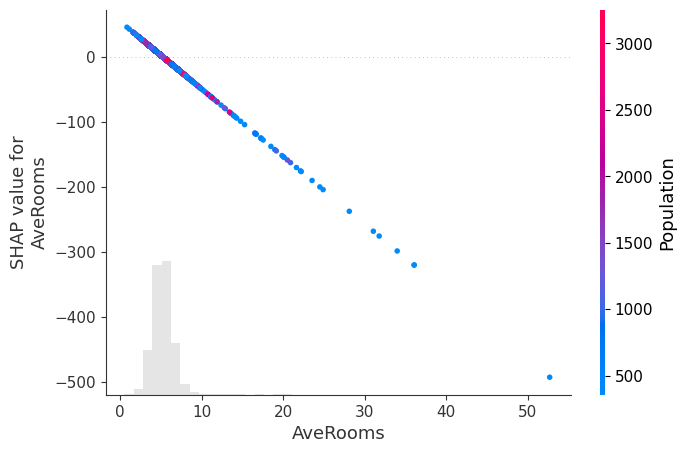

In [217]:
shap.plots.scatter(shap_values[:, "AveRooms"], color=shap_values)

# Conclusion

The linear model achieved a MAE of 38.89, a mean absolute percentage error MAPE of 31.01%, a RMSE of 64.11 and an $R^2$ of 0.5673. According to the SHAP analysis, location and median income in the neighborhood are the primary factors driving housing prices. 

However, SHAP explanations are only as reliable as the underlying model itself. Since the linear model exhibits considerable uncertainty in its predictions, the resulting SHAP values should therefore be interpreted with caution. Nevertheless, within the relationships captured by the linear model, SHAP consistently identifies location and median income as the most influential factors for predicting housing prices.
